# Analyse exploratoire - ElectricityConsumption

In [24]:

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Chargement de données

In [25]:
df = pd.read_csv("../data/processed/dataset_final.csv")
df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)
df.head()

,timestamp_utc,timestamp_paris,consommation_mw,source_donnee,heure,jour_semaine,jour_annee,mois,annee,saison,...,temperature_c_pondere_pop,temperature_point_rosee_c_pondere_pop,humidite_pct_pondere_pop,vent_direction_deg_pondere_pop,vent_vitesse_ms_pondere_pop,nebulosite_pondere_pop,precip_1h_mm_pondere_pop,weekend,ferie,vacances
0,2016-01-01 00:00:00+00:00,2016-01-01 01:00:00+01:00,56569.0,Données définitives,1,4,1,1,2016,Hiver,...,7.161313,6.036176,92.699710,141.342131,1.398133,87.926456,0.000000,False,True,3
1,2016-01-01 01:00:00+00:00,2016-01-01 02:00:00+01:00,55506.5,Données définitives,2,4,1,1,2016,Hiver,...,6.617959,5.651121,93.667847,145.044523,1.230233,87.187606,0.000000,False,True,3
2,2016-01-01 02:00:00+00:00,2016-01-01 03:00:00+01:00,52404.0,Données définitives,3,4,1,1,2016,Hiver,...,6.074606,5.266066,94.635983,148.746916,1.062332,86.448757,0.000000,False,True,3
3,2016-01-01 03:00:00+00:00,2016-01-01 04:00:00+01:00,49776.0,Données définitives,4,4,1,1,2016,Hiver,...,5.531252,4.881011,95.604120,152.449308,0.894432,86.546508,0.000000,False,True,3
4,2016-01-01 04:00:00+00:00,2016-01-01 05:00:00+01:00,48761.0,Données définitives,5,4,1,1,2016,Hiver,...,5.303669,4.737056,96.119515,167.471301,1.000966,82.983612,0.003004,False,True,3


In [26]:
print(df.shape)
df.head()

(94224, 28)


,timestamp_utc,timestamp_paris,consommation_mw,source_donnee,heure,jour_semaine,jour_annee,mois,annee,saison,...,temperature_c_pondere_pop,temperature_point_rosee_c_pondere_pop,humidite_pct_pondere_pop,vent_direction_deg_pondere_pop,vent_vitesse_ms_pondere_pop,nebulosite_pondere_pop,precip_1h_mm_pondere_pop,weekend,ferie,vacances
0,2016-01-01 00:00:00+00:00,2016-01-01 01:00:00+01:00,56569.0,Données définitives,1,4,1,1,2016,Hiver,...,7.161313,6.036176,92.699710,141.342131,1.398133,87.926456,0.000000,False,True,3
1,2016-01-01 01:00:00+00:00,2016-01-01 02:00:00+01:00,55506.5,Données définitives,2,4,1,1,2016,Hiver,...,6.617959,5.651121,93.667847,145.044523,1.230233,87.187606,0.000000,False,True,3
2,2016-01-01 02:00:00+00:00,2016-01-01 03:00:00+01:00,52404.0,Données définitives,3,4,1,1,2016,Hiver,...,6.074606,5.266066,94.635983,148.746916,1.062332,86.448757,0.000000,False,True,3
3,2016-01-01 03:00:00+00:00,2016-01-01 04:00:00+01:00,49776.0,Données définitives,4,4,1,1,2016,Hiver,...,5.531252,4.881011,95.604120,152.449308,0.894432,86.546508,0.000000,False,True,3
4,2016-01-01 04:00:00+00:00,2016-01-01 05:00:00+01:00,48761.0,Données définitives,5,4,1,1,2016,Hiver,...,5.303669,4.737056,96.119515,167.471301,1.000966,82.983612,0.003004,False,True,3


## preparation

In [27]:
#ici le timestamp_utc serait lue comme du texte ,et il faut la convertir en vraie date pour pouvoir filtrer, trier ou grouper par jour 
df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)

In [28]:
#le jour calendaire à Paris
df["date"] = df["timestamp_utc"].dt.tz_convert("Europe/Paris").dt.tz_localize(None).dt.normalize()


## 0. Apercu

In [30]:
print("Période :", df["timestamp_utc"].min(), "->", df["timestamp_utc"].max())
print(df["consommation_mw"].describe().round(0))


Période : 2016-01-01 00:00:00+00:00 -> 2026-09-30 23:00:00+00:00
count    94224.0
mean     52158.0
std      11400.0
min      29364.0
25%      43609.0
50%      50312.0
75%      59694.0
max      96130.0
Name: consommation_mw, dtype: float64


- l'écart type est inférieur à la moyenne à peu près de 22% , ceci est normale puisque la conso varie avec les changement d'heure et de saisons

In [31]:
print("Valeurs manquantes (conso) :", df["consommation_mw"].isna().sum())


Valeurs manquantes (conso) : 0


In [34]:

# Conso moyenne par année (2026 est incomplète : il manque octobre-décembre, donc pas comparable)
print(df.groupby("annee")["consommation_mw"].mean().round(0))

annee
2016    54680.0
2017    54685.0
2018    54282.0
2019    53707.0
2020    50840.0
2021    53491.0
2022    51386.0
2023    49722.0
2024    50100.0
2025    50671.0
2026    49511.0
Name: consommation_mw, dtype: float64


- La tendance est donc à la baisse (on a un niveau de départ (2016->2018)->début de baisse(2019)-> chute liée au covid(2020)-> rebond(2021)-> baisse(2022)-> rebond(2023)-> baisse(2024->2026) )

qq chose à garder en tete: Un modèle entraîné sur des années anciennes verrait un niveau trop haut pour aujourd'hui. Il surestimerait systématiquement la conso.

In [33]:

# Répartition des lignes selon la fiabilité de la source
print(df["source_donnee"].value_counts())
print(df.groupby("source_donnee")["date"].agg(["min", "max"]))


source_donnee
Données définitives    78902
Données consolidées    13102
Données temps réel      2210
interpole                 10
Name: count, dtype: int64
                           min        max
source_donnee                            
Données consolidées 2025-01-01 2026-06-30
Données définitives 2016-01-01 2024-12-31
Données temps réel  2026-07-01 2026-10-01
interpole           2016-10-30 2025-10-26


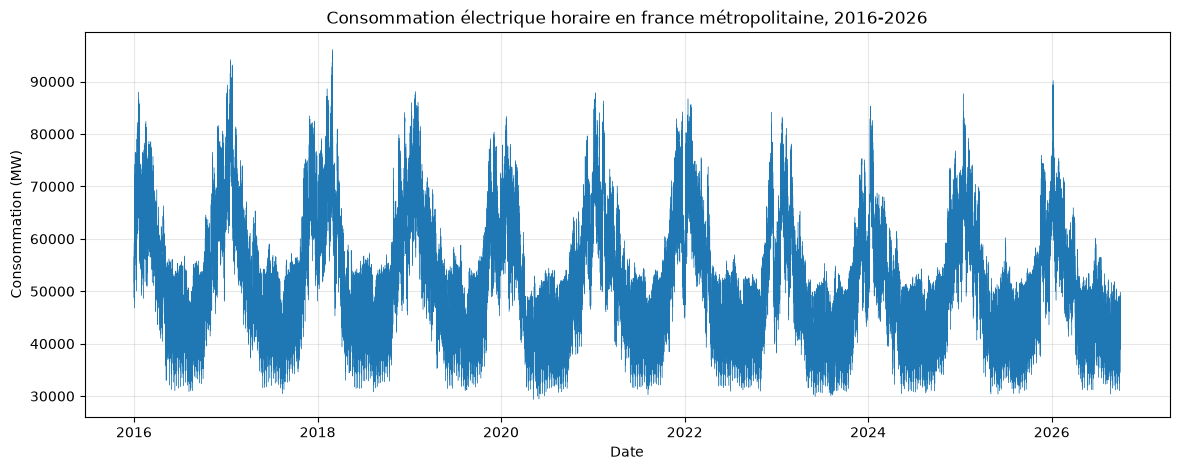

In [36]:
# Consommation horaire sur toute la période
plt.figure(figsize=(14, 5))
plt.plot(df["timestamp_utc"], df["consommation_mw"], lw=.3)
plt.xlabel("Date")
plt.ylabel("Consommation (MW)")
plt.title("Consommation électrique horaire en france métropolitaine, 2016-2026")
plt.grid(alpha=.3)
plt.show()

## 1. Cycle horaire

In [ ]:
# On retire les jours de confinement (confinement_numero est vide en dehors) pour qu'ils ne faussent pas les profils
hors_covid = df[df["confinement_numero"].isna()]

ouvres    = hors_covid[(hors_covid["jour_semaine"] < 5)  & (~hors_covid["ferie"])]
samedis   = hors_covid[(hors_covid["jour_semaine"] == 5) & (~hors_covid["ferie"])]
dimanches = hors_covid[(hors_covid["jour_semaine"] == 6) & (~hors_covid["ferie"])]
feries    = hors_covid[hors_covid["ferie"]]

In [ ]:
# Profil horaire d'un jour ouvré, une courbe par saison
profil = ouvres.groupby(["saison", "heure"])["consommation_mw"].mean().unstack(0)

profil.plot(figsize=(9, 5), xticks=range(0, 24, 2), grid=True)
plt.xlabel("Heure (Paris)")
plt.ylabel("Consommation moyenne (MW)")
plt.title("Profil horaire d'un jour ouvré, par saison")
plt.show()

print("Heure du pic   :", profil.idxmax().to_dict())
print("Heure du creux :", profil.idxmin().to_dict())

In [ ]:
# Profil horaire selon le type de jour (toutes saisons confondues)
types = pd.DataFrame({
    "Ouvré":    ouvres.groupby("heure")["consommation_mw"].mean(),
    "Samedi":   samedis.groupby("heure")["consommation_mw"].mean(),
    "Dimanche": dimanches.groupby("heure")["consommation_mw"].mean(),
    "Férié":    feries.groupby("heure")["consommation_mw"].mean()})

types.plot(figsize=(9, 5), xticks=range(0, 24, 2), grid=True)
plt.xlabel("Heure (Paris)")
plt.ylabel("Consommation moyenne (MW)")
plt.title("Profil horaire selon le type de jour")
plt.show()

p = types["Ouvré"]
print(f"Jour ouvré : creux à {p.idxmin()} h ({p.min():.0f} MW), pic à {p.idxmax()} h ({p.max():.0f} MW)")

### Observations

- Forme des profils (creux, pics matin/soir) :
- Différences hiver / été, ouvré / week-end :
- Conséquence pour la modélisation (24 modèles séparés ou joint ?) :


## 2. Cycle hebdomadaire

In [ ]:
# Table journalière : une ligne par jour de Paris (sert à toutes les analyses à l'échelle du jour)
daily = df.groupby("date").agg(
    conso_moy=("consommation_mw", "mean"),
    conso_max=("consommation_mw", "max"),
    n_heures=("consommation_mw", "count"),
    temp=("temperature_c", "mean"),
    temp_pop=("temperature_c_pondere_pop", "mean"),
    jour_semaine=("jour_semaine", "first"),
    ferie=("ferie", "first"),
    saison=("saison", "first"),
    mois=("mois", "first"),
    annee=("annee", "first"),
    confinement=("confinement_numero", "max"),   # numéro du confinement (vide hors confinement)
    vacances=("vacances", "first"))

daily = daily[daily["n_heures"] >= 23]   # jours complets (23, 24 ou 25 heures) : écarte le dernier jour, tronqué
daily_hc = daily[daily["confinement"].isna()]   # même table sans les jours de confinement
daily.head()

In [ ]:
jours = ["Lun", "Mar", "Mer", "Jeu", "Ven", "Sam", "Dim"]

# Jours fériés exclus : un lundi férié consomme comme un dimanche, il fausserait la boîte du lundi
semaine = daily_hc[~daily_hc["ferie"]]

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

ax[0].boxplot([semaine.loc[semaine["jour_semaine"] == i, "conso_moy"] for i in range(7)])
ax[0].set_xticklabels(jours)
ax[0].set_title("Conso moyenne journalière par jour de la semaine")
ax[0].set_ylabel("MW")

heat = hors_covid[~hors_covid["ferie"]].groupby(["jour_semaine", "heure"])["consommation_mw"].mean().unstack()
im = ax[1].imshow(heat.values, aspect="auto", cmap="viridis")
ax[1].set_yticks(range(7))
ax[1].set_yticklabels(jours)
ax[1].set_xlabel("Heure (Paris)")
ax[1].set_title("Profil moyen (jour × heure)")
plt.colorbar(im, ax=ax[1], label="MW")
plt.show()

m = semaine.groupby("jour_semaine")["conso_moy"].mean()
print(m.round(0).rename(dict(enumerate(jours))))
print(f"Semaine (lun-ven) vs dimanche : {m.loc[0:4].mean() / m.loc[6] - 1:+.1%}")
print(f"Lundi vs mar-jeu : {m.loc[0] / m.loc[1:3].mean() - 1:+.1%} | "
      f"Vendredi vs mar-jeu : {m.loc[4] / m.loc[1:3].mean() - 1:+.1%}")

### Observations

- Écart semaine / week-end :
- Lundi et vendredi (effets de transition) :


## 3. Saisonnalite annuelle et tendance

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(13, 9))

ax[0].plot(daily.index, daily["conso_moy"], lw=.5, alpha=.6, label="Conso journalière")
ax[0].plot(daily["conso_moy"].rolling(365, min_periods=300).mean(),
           color="red", lw=2, label="Moyenne mobile 365 jours")
covid = daily[daily["confinement"].notna()]
ax[0].scatter(covid.index, covid["conso_moy"], s=4, color="grey", label="Jours de confinement")
ax[0].set_title("Consommation moyenne journalière")
ax[0].set_ylabel("MW")
ax[0].legend()

mm = daily.groupby(["annee", "mois"])["conso_moy"].mean().unstack()
im = ax[1].imshow(mm.values, aspect="auto", cmap="coolwarm")
ax[1].set_yticks(range(len(mm.index)))
ax[1].set_yticklabels(mm.index)
ax[1].set_xticks(range(12))
ax[1].set_xticklabels(range(1, 13))
ax[1].set_xlabel("Mois")
ax[1].set_title("Conso moyenne par année × mois (cases vides : pas encore de données)")
plt.colorbar(im, ax=ax[1], label="MW")
plt.tight_layout()
plt.show()

mo = daily_hc.groupby("mois")["conso_moy"].mean()
print(mo.round(0))
print(f"Ratio janvier / (juillet-août) : {mo.loc[1] / mo.loc[[7, 8]].mean():.2f}")

### Observations

- Amplitude saisonnière (janvier vs été) :
- Tendance de fond sur 10 ans :


## 4. Relation conso / meteo

In [ ]:
# Jours ouvrés sans confinement ni férié : on isole l'effet de la température
jours_ouvres = daily_hc[(daily_hc["jour_semaine"] < 5) & (~daily_hc["ferie"])]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, col, titre in zip(axes, ["temp", "temp_pop"], ["Moyenne simple", "Pondérée par la population"]):
    d = jours_ouvres[[col, "conso_moy", "mois"]].dropna()
    x, y = d[col], d["conso_moy"]

    sc = ax.scatter(x, y, c=d["mois"], cmap="twilight", s=6)

    # parabole ajustée sur le nuage : son R² mesure la netteté de la relation en U
    a, b, c = np.polyfit(x, y, 2)
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, a * xs**2 + b * xs + c, color="red")
    r2 = 1 - ((y - (a * x**2 + b * x + c))**2).sum() / ((y - y.mean())**2).sum()

    ax.set_title(f"{titre} (R² = {r2:.3f})")
    ax.set_xlabel("Température moyenne journalière (°C)")
    ax.grid(alpha=.3)

    froid, chaud = x < 12, x > 20
    print(f"{col:9s} R² = {r2:.3f} | minimum de conso à {-b / (2 * a):.1f} °C | "
          f"pente à froid (<12 °C) = {np.polyfit(x[froid], y[froid], 1)[0]:.0f} MW/°C | "
          f"pente à chaud (>20 °C) = {np.polyfit(x[chaud], y[chaud], 1)[0]:.0f} MW/°C")

axes[0].set_ylabel("Conso moyenne (MW)")
fig.colorbar(sc, ax=axes, label="Mois")
plt.show()

print(df[["temperature_c", "temperature_c_pondere_pop"]].isna().sum())   # heures sans mesure

### Observations

- Température du minimum de conso :
- Pente à froid vs à chaud :
- Température simple ou pondérée (R²) → choix :


## 5. Effets calendaires

In [ ]:
# Férié en semaine vs jour normal du même jour de semaine
# (comparaison simple : les fériés tombent à des saisons particulières, l'écart mélange donc un peu de saisonnalité)
semaine_hc = daily_hc[daily_hc["jour_semaine"] < 5]

print("Écart de conso : jour férié vs jour non férié, même jour de semaine")
for i in range(5):
    f = semaine_hc[(semaine_hc["jour_semaine"] == i) & semaine_hc["ferie"]]["conso_moy"]
    n = semaine_hc[(semaine_hc["jour_semaine"] == i) & ~semaine_hc["ferie"]]["conso_moy"]
    if len(f) > 3:
        print(f"  {jours[i]} : n={len(f):3d}  écart = {f.mean() / n.mean() - 1:+.1%}")

# Vacances : jours ouvrés, puis même chose à température comparable pour ne pas confondre vacances et saison
frais = jours_ouvres[(jours_ouvres["temp_pop"] > 8) & (jours_ouvres["temp_pop"] < 14)]

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
jours_ouvres.boxplot(column="conso_moy", by="vacances", ax=ax[0])
ax[0].set_title("Jours ouvrés")
frais.boxplot(column="conso_moy", by="vacances", ax=ax[1])
ax[1].set_title("Jours ouvrés, température pondérée entre 8 et 14 °C")
for a in ax:
    a.set_xlabel("Nombre de zones en vacances")
    a.set_ylabel("MW")
plt.suptitle("")
plt.show()

print(jours_ouvres.groupby("vacances")["conso_moy"].agg(["count", "mean"]).round(0))
print(frais.groupby("vacances")["conso_moy"].agg(["count", "mean"]).round(0))

### Observations

- Effet des jours fériés :
- Effet des vacances (à température comparable) :


## 6. Ruptures et observations atypiques

In [ ]:
# Écart de chaque jour à la médiane des mêmes jours de semaine voisins (±4 semaines)
# asfreq("D") remet les jours absents (NaN) pour que les décalages de 7 jours tombent bien sur le même jour de semaine
s = daily["conso_moy"].asfreq("D")
ref = pd.concat([s.shift(7 * k) for k in (-4, -3, -2, -1, 1, 2, 3, 4)], axis=1).median(axis=1)
resid = (s / ref - 1).dropna()
z = (resid - resid.median()) / (1.4826 * (resid - resid.median()).abs().median())

top = z.abs().sort_values(ascending=False).head(20).index
atypiques = pd.DataFrame({
    "jour": daily.loc[top, "jour_semaine"].map(dict(enumerate(jours))),
    "écart": resid[top].round(3),
    "z": z[top].round(1),
    "ferie": daily.loc[top, "ferie"],
    "confinement": daily.loc[top, "confinement"]})
print(atypiques)

plt.figure(figsize=(13, 4.5))
plt.plot(resid.index, resid * 100, lw=.5)
covid_idx = resid.index[daily.loc[resid.index, "confinement"].notna().values]
plt.scatter(covid_idx, resid[covid_idx] * 100, s=6, color="grey", label="Jours de confinement")
plt.ylabel("Écart (%)")
plt.title("Écart de la conso journalière à la médiane des mêmes jours de semaine voisins")
plt.legend()
plt.grid(alpha=.3)
plt.show()

In [ ]:
# Maximum horaire de chaque année
pics = df.loc[df.groupby("annee")["consommation_mw"].idxmax(), ["timestamp_paris", "consommation_mw"]]
print(pics.to_string(index=False))

In [ ]:
# Effet de chaque confinement : conso pendant la période vs mêmes dates les années voisines (sans confinement)
for num, g in daily.groupby("confinement"):
    debut, fin = g.index.min(), g.index.max()
    pendant = g["conso_moy"].mean()

    ref = []
    for dy in (-1, 1):
        d1, d2 = debut + pd.DateOffset(years=dy), fin + pd.DateOffset(years=dy)
        autre = daily.loc[d1:d2]
        if len(autre) > 20 and autre["confinement"].isna().all():
            ref.append(autre["conso_moy"].mean())

    if ref:
        print(f"Confinement {int(num)} ({debut.date()} -> {fin.date()}) : {pendant / np.mean(ref) - 1:+.1%} vs mêmes dates des années voisines")

### Observations

- Effet des 3 confinements :
- Jours atypiques à garder pour l'analyse des échecs (au moins 3) :
- Décision Covid : exclure de l'entraînement ou non (à trancher sur train/validation) :


## 7. Changements d'heure

In [ ]:
# Nombre d'heures par jour de Paris : 24 normalement, 23 au passage à l'heure d'été, 25 à l'heure d'hiver
cnt = df.groupby("date")["consommation_mw"].count()

# Premier et dernier jour sont tronqués (le fichier commence/finit à minuit UTC, pas à minuit Paris) : on les met de côté
print("Jours tronqués aux bornes :", cnt.iloc[[0, -1]].to_dict())
cnt = cnt.iloc[1:-1]

print(cnt.value_counts().sort_index())

bad  = cnt[cnt == 23]
good = cnt[cnt == 25]
print("Jours à 23 h (heure d'été) :", len(bad), [d.strftime("%Y-%m-%d") for d in bad.index])
print("Jours à 25 h (heure d'hiver) :", len(good), [d.strftime("%Y-%m-%d") for d in good.index])
print("Jours avec un nombre d'heures inattendu (hors 23/24/25) :", len(cnt[~cnt.isin([23, 24, 25])]))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for a, jours_dst, titre in [(ax[0], bad.index, "Passage à l'heure d'été (23 h)"),
                            (ax[1], good.index, "Passage à l'heure d'hiver (25 h)")]:
    for d in jours_dst:
        conso_jour = df.loc[df["date"] == d, "consommation_mw"].values
        a.plot(range(len(conso_jour)), conso_jour, alpha=.5)
    a.set_title(titre)
    a.set_xlabel("Rang de l'heure dans la journée")
    a.grid(alpha=.3)
plt.show()

### Observations

- Nombre d'heures par jour (23 / 24 / 25) conforme ?
- Traitement retenu :


## Décisions pour la suite

- Cible et période d'entraînement / validation / test :
- Température retenue (simple ou pondérée) :
- Covid (exclusion ou variables `covid19`, `confinement_numero`) :
- 24 modèles séparés ou prévision conjointe :
- Jours atypiques retenus pour l'analyse des échecs :
